In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
bhavikjikadara_car_price_prediction_dataset_path = kagglehub.dataset_download('bhavikjikadara/car-price-prediction-dataset')

print('Data source import complete.')


In [ ]:
import pandas as pd

**Task 1**

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/bhavikjikadara/car-price-prediction-dataset/car_prediction_data.csv")
#loading the dataset

In [ ]:
df.head(5)
#first five rows

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.tail(5)
#last five rows

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
df.shape
#shape of dataset

(301, 9)

In [ ]:
df.columns
#names of columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
df.dtypes
#datatypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

**Task 2**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.isna().sum()
#missing values

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [ ]:
df.duplicated().sum()
#duplicate rows

np.int64(2)

In [ ]:
df.drop_duplicates(inplace = True)
#dropping duplicates

**Task 3**

In [ ]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [ ]:
df['Fuel_Type_int'] = df['Fuel_Type'].apply(lambda x : 0 if x == 'Petrol' else 1 if x == 'Diesel' else 2)

In [ ]:
df['Seller_Type_int'] = df['Seller_Type'].apply(lambda x : 0 if x == 'Dealer' else 1)

In [ ]:
df['Transmission_int'] = df['Transmission'].apply(lambda x : 0 if x == 'Manual' else 1)

In [ ]:
df.drop(columns = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], inplace = True)

In [ ]:
X = df.drop(columns = ['Selling_Price'])
y = df['Selling_Price']

**Task 4**

In [ ]:
df.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner',
       'Fuel_Type_int', 'Seller_Type_int', 'Transmission_int'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt

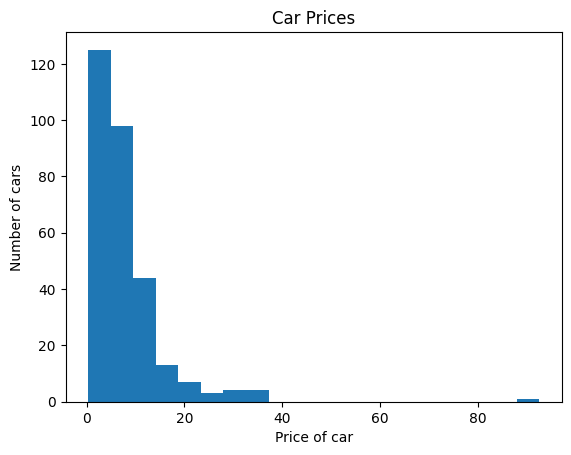

In [ ]:
plt.hist(df['Present_Price'], bins = 20)
plt.title('Car Prices')
plt.xlabel('Price of car')
plt.ylabel('Number of cars')
plt.show()

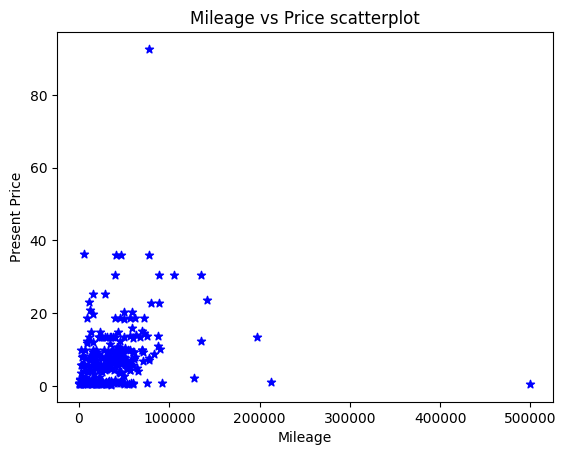

In [ ]:
plt.scatter(df['Kms_Driven'], df['Present_Price'], color = 'blue', marker = '*')
plt.xlabel('Mileage')
plt.ylabel('Present Price')
plt.title('Mileage vs Price scatterplot')
plt.show()

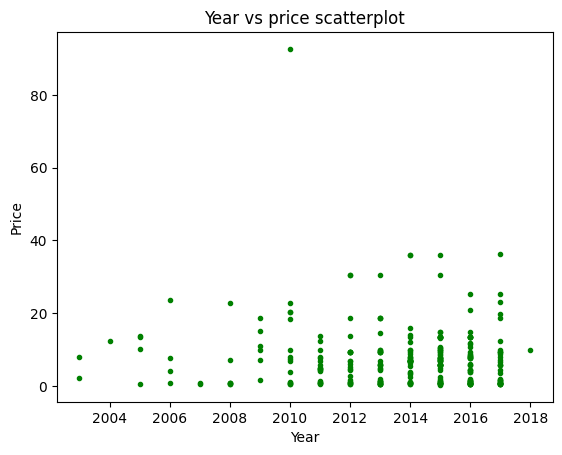

In [ ]:
plt.scatter(df['Year'], df['Present_Price'], color = 'green', marker = '.')
plt.title('Year vs price scatterplot')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

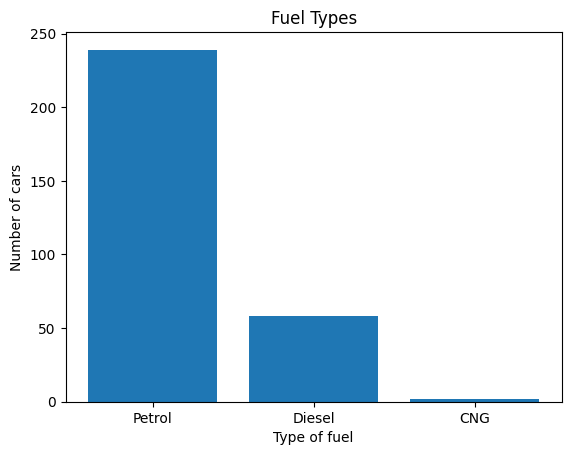

In [ ]:
fuel_counts = df['Fuel_Type_int'].value_counts().sort_index()
plt.bar(fuel_counts.index.astype(str), fuel_counts.values)
plt.title('Fuel Types')
plt.xlabel('Type of fuel')
plt.ylabel('Number of cars')
plt.xticks(['0', '1', '2'], ['Petrol', 'Diesel', 'CNG'])
plt.show()

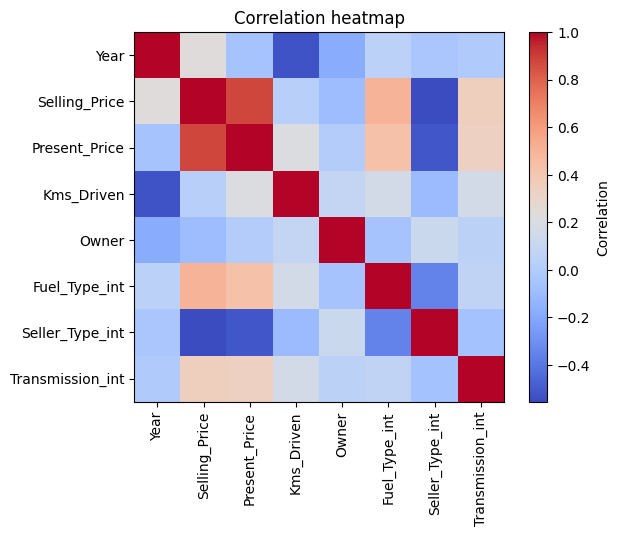

In [ ]:
corr = df.corr(numeric_only = True)
plt.imshow(corr, cmap = 'coolwarm', interpolation = 'nearest')
plt.colorbar(label = 'Correlation')
plt.title('Correlation heatmap')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

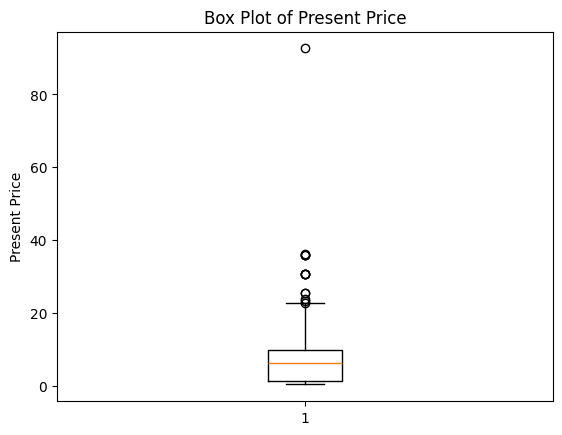

In [ ]:
plt.boxplot(df['Present_Price'])
plt.title("Box Plot of Present Price")
plt.ylabel("Present Price")
plt.show()

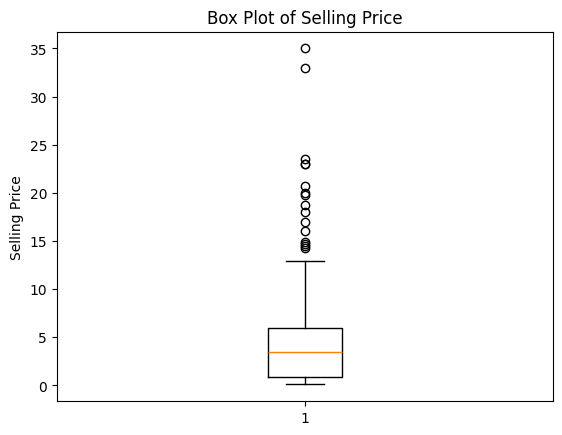

In [ ]:
plt.boxplot(df['Selling_Price'])
plt.title("Box Plot of Selling Price")
plt.ylabel("Selling Price")
plt.show()

**Task 5**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

**Task 6**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

**Task 7**

In [ ]:
from sklearn.metrics import mean_absolute_error
print("Mean Absolute Error (MAE): ")
print(mean_absolute_error(y_test, y_pred))

Mean Absolute Error (MAE): 
1.6008063518603204


In [ ]:
from sklearn.metrics import mean_squared_error
print("Mean Squared Error(MSE): ")
print(mean_squared_error(y_test, y_pred))

Mean Squared Error(MSE): 
6.892176958730504


In [ ]:
print("Root Mean Squared Error(RMSE): ")
print(mean_squared_error(y_test, y_pred) ** 0.5)

Root Mean Squared Error(RMSE): 
2.6252955945436893


In [ ]:
from sklearn.metrics import r2_score
print("R2 Score: ")
print(r2_score(y_test, y_pred))

R2 Score: 
0.7325842223888938


**Task 8**

In [ ]:
sample = X_test[0].reshape(1, -1)
predicted_price = model.predict(sample)
print("Predicted Price: ", predicted_price[0])
print("Actual Price: ", y_test.iloc[0])

Predicted Price:  7.561848399959472
Actual Price:  8.99
